### *ANALYZING STRESS IN A WORKPLACE*

## Introduction
This data comes from [kaggle](https://www.kaggle.com/datasets/shijo96john/stress-level-prediction) that 
comprises of Age, Occupation, lifestyle choices, health and stress levels of employees in an organisation.

## Objectives
* Explore how the impact of lifestyle in relation to stress levels
* Explore Age and Health in relation to Stress Levels
* Explore how work_related factors in relation to stress levels
* Use correlation and data visualization to explore these relationships and gain insights 


### Loading The Dataset

In [1]:
# import the necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
stress_df = pd.read_csv('stress_detection_data.csv')


### Data Understanding

In [3]:
# The first five rows
stress_df.head()

,Age,Gender,Occupation,Marital_Status,Sleep_Duration,Sleep_Quality,Wake_Up_Time,Bed_Time,Physical_Activity,Screen_Time,...,Smoking_Habit,Work_Hours,Travel_Time,Social_Interactions,Meditation_Practice,Exercise_Type,Blood_Pressure,Cholesterol_Level,Blood_Sugar_Level,Stress_Detection
0,30,Male,Software Engineer,Single,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,No,8,1.0,5,Yes,Cardio,120,180,90,Low
1,35,Female,Marketing Manager,Married,6.0,3.0,6:00 AM,11:00 PM,1.0,3.0,...,No,9,2.0,3,No,Yoga,110,160,80,Medium
2,40,Male,Data Scientist,Divorced,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,No,8,1.0,5,Yes,Strength Training,130,200,100,High
3,35,Male,Software Engineer,Single,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,No,8,1.0,5,Yes,Cardio,120,180,90,Low
4,29,Female,Teacher,Single,8.0,5.0,6:30 AM,10:30 PM,3.0,2.0,...,No,7,1.0,4,Yes,Yoga,110,180,90,Low


In [4]:
# The last 5 rows
stress_df.tail()

,Age,Gender,Occupation,Marital_Status,Sleep_Duration,Sleep_Quality,Wake_Up_Time,Bed_Time,Physical_Activity,Screen_Time,...,Smoking_Habit,Work_Hours,Travel_Time,Social_Interactions,Meditation_Practice,Exercise_Type,Blood_Pressure,Cholesterol_Level,Blood_Sugar_Level,Stress_Detection
768,40,Female,Teacher,Single,6.3,4.0,7:00 AM,5:00 PM,3.0,4.0,...,No,7,3.0,2,No,Yoga,155,235,120,Medium
769,42,Male,Writer,Married,6.0,3.7,8:00 AM,6:00 PM,3.0,4.0,...,No,7,3.0,2,No,Strength Training,150,230,115,Low
770,30,Female,Accountant,Single,6.1,3.8,7:00 AM,5:00 PM,4.0,5.0,...,Yes,7,3.0,2,Yes,Cardio,155,235,120,High
771,34,Male,Architect,Married,6.2,3.9,7:00 AM,6:00 PM,3.0,4.0,...,No,7,3.0,2,No,Strength Training,160,240,125,Medium
772,29,Female,Scientist,Single,6.3,4.2,8:00 AM,5:00 PM,4.0,5.0,...,Yes,8,4.0,3,Yes,Yoga,150,230,115,High


In [5]:
# The shape of the data
stress_df.shape

(773, 22)

In [6]:

stress_df.columns

Index(['Age', 'Gender', 'Occupation', 'Marital_Status', 'Sleep_Duration',
       'Sleep_Quality', 'Wake_Up_Time', 'Bed_Time', 'Physical_Activity',
       'Screen_Time', 'Caffeine_Intake', 'Alcohol_Intake', 'Smoking_Habit',
       'Work_Hours', 'Travel_Time', 'Social_Interactions',
       'Meditation_Practice', 'Exercise_Type', 'Blood_Pressure',
       'Cholesterol_Level', 'Blood_Sugar_Level', 'Stress_Detection'],
      dtype='object')

In [7]:
# Brief description of the data
stress_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 773 entries, 0 to 772
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  773 non-null    int64  
 1   Gender               773 non-null    object 
 2   Occupation           773 non-null    object 
 3   Marital_Status       773 non-null    object 
 4   Sleep_Duration       773 non-null    float64
 5   Sleep_Quality        773 non-null    float64
 6   Wake_Up_Time         773 non-null    object 
 7   Bed_Time             773 non-null    object 
 8   Physical_Activity    773 non-null    float64
 9   Screen_Time          773 non-null    float64
 10  Caffeine_Intake      773 non-null    int64  
 11  Alcohol_Intake       773 non-null    int64  
 12  Smoking_Habit        773 non-null    object 
 13  Work_Hours           773 non-null    int64  
 14  Travel_Time          773 non-null    float64
 15  Social_Interactions  773 non-null    int

In [8]:
stress_df.describe()

,Age,Sleep_Duration,Sleep_Quality,Physical_Activity,Screen_Time,Caffeine_Intake,Alcohol_Intake,Work_Hours,Travel_Time,Social_Interactions,Blood_Pressure,Cholesterol_Level,Blood_Sugar_Level
count,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000,773.000000
mean,38.887451,6.338422,3.848124,2.979301,4.105433,1.818887,0.888745,8.258732,2.858344,3.196636,137.943079,220.834411,111.765847
std,7.686642,0.733584,0.545459,0.797234,0.812513,0.838396,0.673741,1.064168,1.083758,0.856332,13.122060,19.322622,12.533097
min,18.000000,3.500000,2.000000,1.000000,2.000000,0.000000,0.000000,6.000000,0.500000,1.000000,110.000000,150.000000,80.000000
25%,33.000000,6.000000,3.600000,2.000000,4.000000,1.000000,0.000000,8.000000,2.000000,3.000000,130.000000,210.000000,105.000000
50%,39.000000,6.300000,3.900000,3.000000,4.000000,2.000000,1.000000,8.000000,3.000000,3.000000,140.000000,220.000000,115.000000
75%,45.000000,7.000000,4.000000,4.000000,5.000000,2.000000,1.000000,9.000000,4.000000,4.000000,150.000000,230.000000,120.000000
max,60.000000,8.000000,5.000000,5.000000,8.000000,4.000000,2.000000,14.000000,5.000000,5.000000,170.000000,290.000000,150.000000


#### Check for Missing Values

In [9]:
# check for null values
stress_df.isnull().any()

Age                    False
Gender                 False
Occupation             False
Marital_Status         False
Sleep_Duration         False
Sleep_Quality          False
Wake_Up_Time           False
Bed_Time               False
Physical_Activity      False
Screen_Time            False
Caffeine_Intake        False
Alcohol_Intake         False
Smoking_Habit          False
Work_Hours             False
Travel_Time            False
Social_Interactions    False
Meditation_Practice    False
Exercise_Type          False
Blood_Pressure         False
Cholesterol_Level      False
Blood_Sugar_Level      False
Stress_Detection       False
dtype: bool

In [10]:
# check for duplicates
stress_df.duplicated().any()

np.False_

## Explore Data Distributions

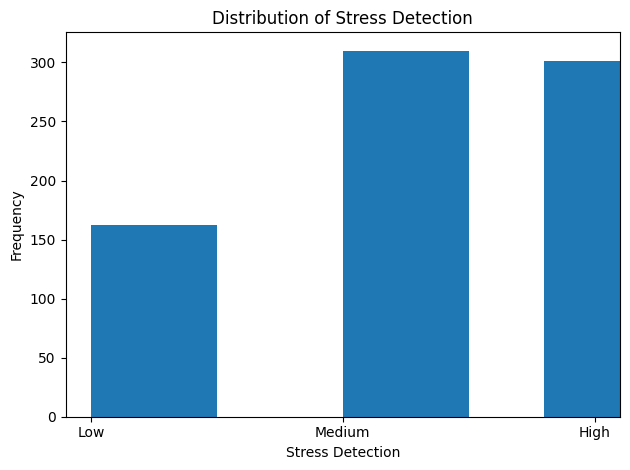

In [11]:
# stress detection distribution
fig, ax = plt.subplots()

ax.hist(stress_df['Stress_Detection'], width=0.5)

ax.set(title=(f'Distribution of Stress Detection'), xlabel='Stress Detection', ylabel='Frequency')

plt.tight_layout()
plt.show()


##### Majority of the employees are in the medium stress category followed closely by the high stress category.

### Explore Impact of Lifestyle Choices on Stress Levels

##### Lifestyle choices columns 

In [12]:
# add a stress level column
stress_mapping = {'Low': 1, 'Medium': 2, 'High': 3}        # assign numerical values to the stress values
stress_df['Stress_Level'] = stress_df['Stress_Detection'].map(stress_mapping)

stress_df.head()

,Age,Gender,Occupation,Marital_Status,Sleep_Duration,Sleep_Quality,Wake_Up_Time,Bed_Time,Physical_Activity,Screen_Time,...,Work_Hours,Travel_Time,Social_Interactions,Meditation_Practice,Exercise_Type,Blood_Pressure,Cholesterol_Level,Blood_Sugar_Level,Stress_Detection,Stress_Level
0,30,Male,Software Engineer,Single,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,8,1.0,5,Yes,Cardio,120,180,90,Low,1
1,35,Female,Marketing Manager,Married,6.0,3.0,6:00 AM,11:00 PM,1.0,3.0,...,9,2.0,3,No,Yoga,110,160,80,Medium,2
2,40,Male,Data Scientist,Divorced,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,8,1.0,5,Yes,Strength Training,130,200,100,High,3
3,35,Male,Software Engineer,Single,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,8,1.0,5,Yes,Cardio,120,180,90,Low,1
4,29,Female,Teacher,Single,8.0,5.0,6:30 AM,10:30 PM,3.0,2.0,...,7,1.0,4,Yes,Yoga,110,180,90,Low,1


In [13]:
lifestyle_columns = ['Sleep_Duration', 'Sleep_Quality', 'Wake_Up_Time', 'Bed_Time', 'Physical_Activity', 'Screen_Time', 'Alcohol_Intake', 'Smoking_Habit', 'Social_Interactions', 'Meditation_Practice', 'Exercise_Type']

In [14]:
# access the numerical columns from the lifestyle columns
numerical_lifestyle = stress_df[lifestyle_columns].select_dtypes(include=['number'])

len(numerical_lifestyle.columns)

6

In [15]:
# ensure that bool columns are excluded
correlation_columns = stress_df[lifestyle_columns].select_dtypes(include=['integer', 'float'])

In [16]:
correlation_columns = ['Sleep_Quality', 'Physical_Activity', 'Screen_Time', 'Alcohol_Intake', 'Social_Interactions', 'Stress_Level']

In [17]:
correlation_matrix = stress_df[correlation_columns].corr()

correlation_matrix

,Sleep_Quality,Physical_Activity,Screen_Time,Alcohol_Intake,Social_Interactions,Stress_Level
Sleep_Quality,1.000000,0.096422,0.020395,0.154168,0.326085,0.012645
Physical_Activity,0.096422,1.000000,0.717269,0.591370,0.085660,0.438701
Screen_Time,0.020395,0.717269,1.000000,0.537296,0.100484,0.495994
Alcohol_Intake,0.154168,0.591370,0.537296,1.000000,-0.018162,0.407026
Social_Interactions,0.326085,0.085660,0.100484,-0.018162,1.000000,0.109784
Stress_Level,0.012645,0.438701,0.495994,0.407026,0.109784,1.000000


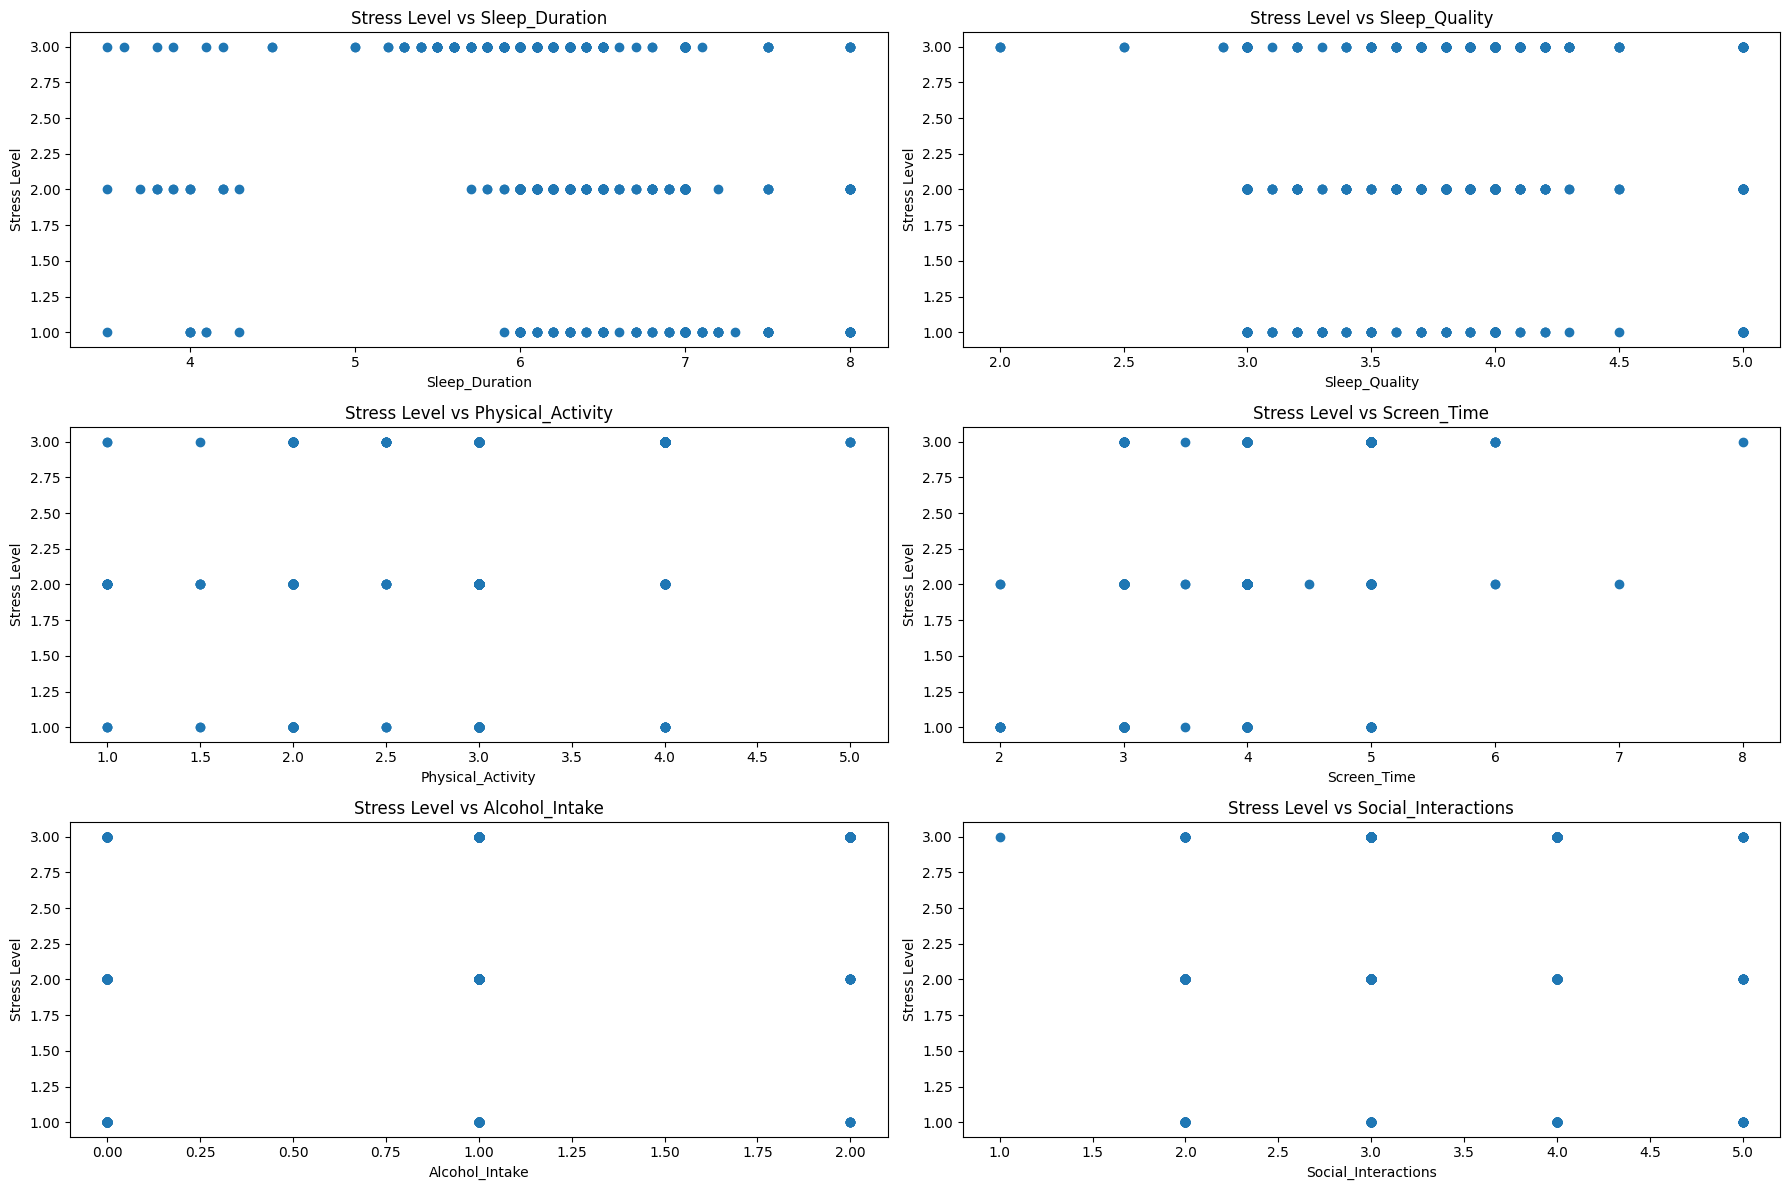

In [18]:
# plot scatter plots for the numerical columns
fig, axes = plt.subplots(3, 2, figsize=(18, 12))

axes = axes.flatten() 

for i, column in enumerate(numerical_lifestyle):
    ax = axes[i] 

    ax.scatter(stress_df[column], stress_df['Stress_Level'])
    
    ax.set(title=(f'Stress Level vs {column}'), xlabel=column, ylabel='Stress Level');

plt.tight_layout()
plt.show()

plt.savefig("lifestyle_choices.png")

In [19]:
# plot categorical lifestyle columns 
categorical_lifestyle = stress_df[lifestyle_columns].select_dtypes(include=['object'])

categorical_lifestyle

,Wake_Up_Time,Bed_Time,Smoking_Habit,Meditation_Practice,Exercise_Type
0,7:00 AM,10:00 PM,No,Yes,Cardio
1,6:00 AM,11:00 PM,No,No,Yoga
2,7:00 AM,10:00 PM,No,Yes,Strength Training
3,7:00 AM,10:00 PM,No,Yes,Cardio
4,6:30 AM,10:30 PM,No,Yes,Yoga
...,...,...,...,...,...
768,7:00 AM,5:00 PM,No,No,Yoga
769,8:00 AM,6:00 PM,No,No,Strength Training
770,7:00 AM,5:00 PM,Yes,Yes,Cardio
771,7:00 AM,6:00 PM,No,No,Strength Training


<Figure size 640x480 with 0 Axes>

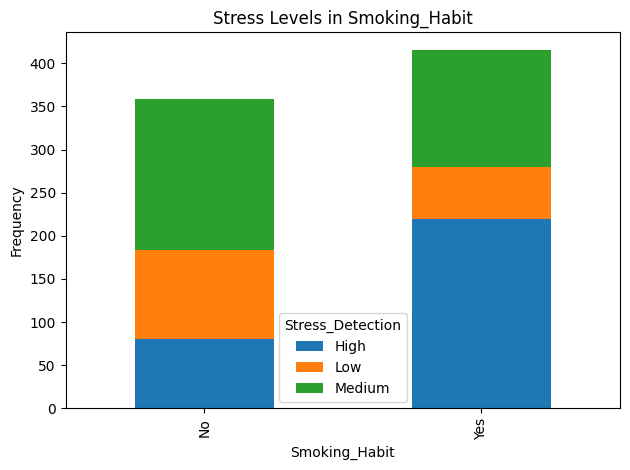

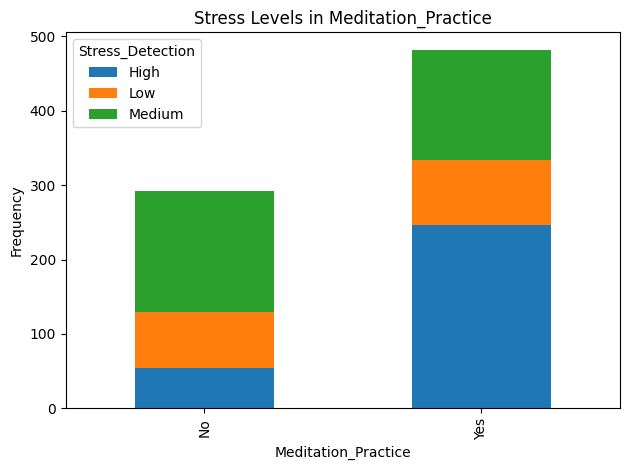

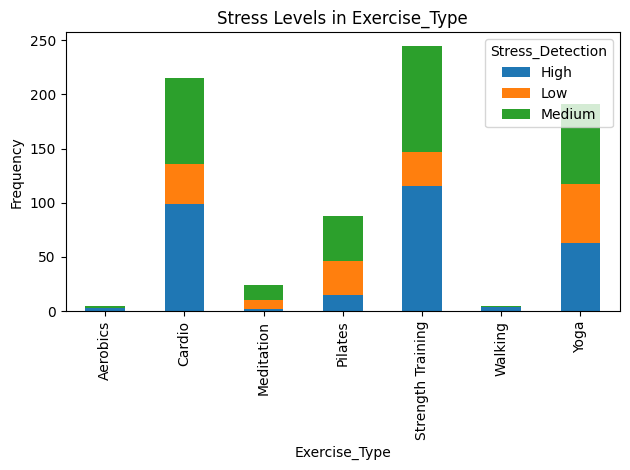

In [20]:
# looping through the categorical columns so as to find the frequency of the stress levels in each column
for column in categorical_lifestyle:
    if column not in ['Wake_Up_Time', 'Bed_Time']: # exclude wake up time and bed time as they are time
       categorical_groupby = stress_df.groupby([column, 'Stress_Detection']).size().unstack()

       # plot bar charts for the categorical column
       fig, ax = plt.subplots()
       categorical_groupby.plot(kind='bar', stacked=True, ax=ax) 

       ax.set(title=(f'Stress Levels in {column}'), xlabel=column, ylabel='Frequency');

       plt.tight_layout()
       plt.show()


plt.savefig("lifestyle_choices_2.png")

### Explore Age and Health in Relation to Stress

In [21]:
health_columns = ['Blood_Pressure', 'Cholesterol_Level', 'Blood_Sugar_Level', 'Stress_Level']


In [22]:
correlation_matrix = stress_df[health_columns].corr()

correlation_matrix

,Blood_Pressure,Cholesterol_Level,Blood_Sugar_Level,Stress_Level
Blood_Pressure,1.000000,0.811789,0.826481,0.502711
Cholesterol_Level,0.811789,1.000000,0.943859,0.532572
Blood_Sugar_Level,0.826481,0.943859,1.000000,0.498705
Stress_Level,0.502711,0.532572,0.498705,1.000000


In [23]:
# create a Pivot table to condense the the data for easier plotting
pivot_table = stress_df.pivot_table(values=['Blood_Pressure', 'Cholesterol_Level', 'Blood_Sugar_Level'], index= ['Age'], columns='Stress_Detection', aggfunc='mean')

pivot_table

Blood_Pressure                         Blood_Sugar_Level  \
Stress_Detection           High         Low      Medium              High   
Age                                                                         
18                          NaN  120.000000  120.000000               NaN   
19                          NaN         NaN  127.500000               NaN   
20                   135.000000         NaN         NaN        115.000000   
21                   130.000000  120.000000  120.000000        105.000000   
22                   127.500000         NaN  140.000000        105.000000   
23                          NaN  120.000000  132.500000               NaN   
24                   130.000000  130.000000  130.000000        110.000000   
25                   125.000000  130.000000  131.666667        100.000000   
26                          NaN         NaN  130.000000               NaN   
27                   141.250000  127.500000  133.750000        116.250000   
28                   143.333333  123.000000  131.000000        101.666667   
29                   141.666667  126.250000  134.230769        111.666667   
30                   138.125000  125.384615  141.428571        106.250000   
31                   141.666667  121.666667  139.000000        105.000000   
32                   142.142857  127.500000  134.375000        107.857143   
33                   141.875000  131.428571  133.823529        111.250000   
34                   146.250000  129.444444  130.789474        114.375000   
35                   138.636364  125.000000  131.153846        112.272727   
36                   148.846154  127.500000  128.684211        123.076923   
37                   145.714286  129.000000  133.823529        117.142857   
38                   147.647059  121.666667  132.105263        120.294118   
39                   143.076923  123.333333  136.315789        118.846154   
40                   146.388889  130.000000  135.000000        120.000000   
41                   138.888889  131.250000  139.000000        115.555556   
42                   140.833333  138.000000  141.000000        120.416667   
43                   146.250000  132.500000  138.750000        123.125000   
44                   147.000000  126.666667  137.000000        125.000000   
45                   140.500000  127.000000  144.500000        117.500000   
46                   150.000000  128.333333  140.500000        128.181818   
47                   148.125000  136.250000  141.428571        120.625000   
48                   146.176471  131.000000  138.333333        124.705882   
49                   147.222222  133.750000  140.000000        121.111111   
50                   151.296296  140.000000  139.375000        125.740741   
51                   160.000000  137.500000  140.000000        130.000000   
52                   155.500000  145.000000  125.000000        124.000000   
53                   152.000000         NaN  156.666667        124.000000   
54                   147.500000  120.000000  158.333333        122.500000   
55                   156.666667         NaN  147.000000        126.666667   
60                          NaN         NaN  140.000000               NaN   

                                         Cholesterol_Level              \
Stress_Detection         Low      Medium              High         Low   
Age                                                                      
18                 97.500000   95.000000               NaN  205.000000   
19                       NaN  105.000000               NaN         NaN   
20                       NaN         NaN        225.000000         NaN   
21                 95.000000  100.000000        220.000000  205.000000   
22                       NaN  115.000000        215.000000         NaN   
23                105.000000  112.500000               NaN  210.000000   
24                110.000000  110.000000        220.000000  225.000000   
25                110.000000  110.000000  

In [24]:
# convert pivot table from wide format to long format making it easier to access our data for plotting
stack_pivot_table = pivot_table.stack(future_stack=True)

stack_pivot_table

Blood_Pressure  Blood_Sugar_Level  Cholesterol_Level
Age Stress_Detection                                                      
18  High                         NaN                NaN                NaN
    Low                        120.0               97.5              205.0
    Medium                     120.0               95.0              200.0
19  High                         NaN                NaN                NaN
    Low                          NaN                NaN                NaN
...                              ...                ...                ...
55  Low                          NaN                NaN                NaN
    Medium                     147.0              118.0              228.0
60  High                         NaN                NaN                NaN
    Low                          NaN                NaN                NaN
    Medium                     140.0              120.0              230.0

[117 rows x 3 columns]

<Figure size 640x480 with 0 Axes>

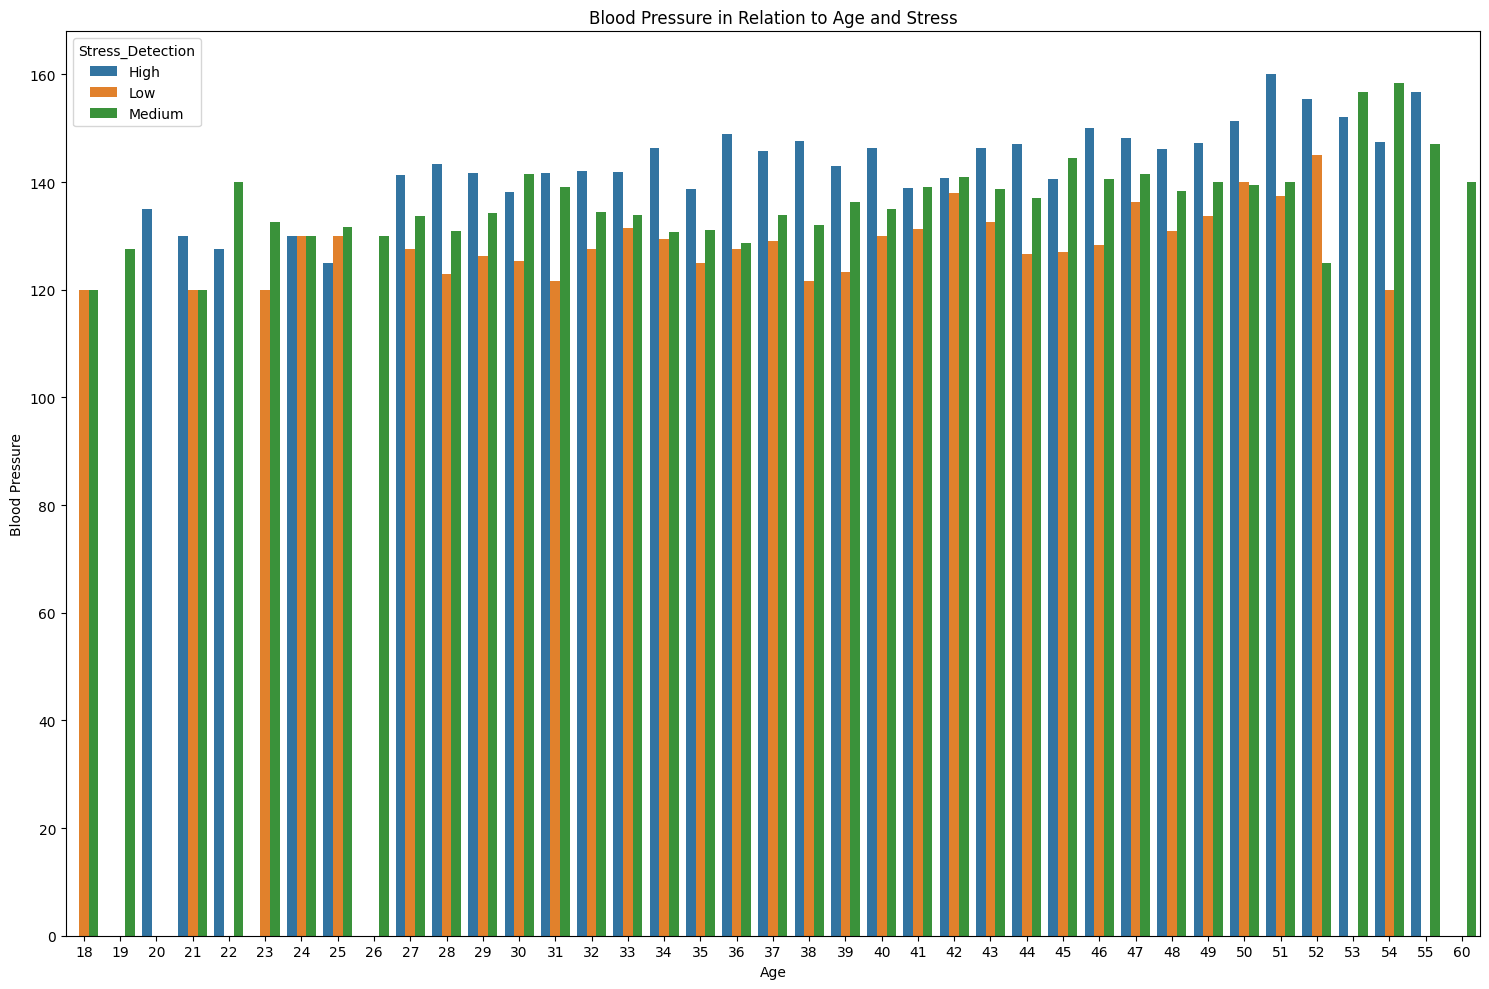

In [25]:
# blood pressure bar plot

fig, ax = plt.subplots(figsize=(15, 10))

sns.barplot(x='Age', y='Blood_Pressure', hue='Stress_Detection', data=stack_pivot_table, ax=ax)

ax.set_title('Blood Pressure in Relation to Age and Stress')
ax.set_xlabel('Age')
ax.set_ylabel('Blood Pressure')

plt.tight_layout()
plt.show()

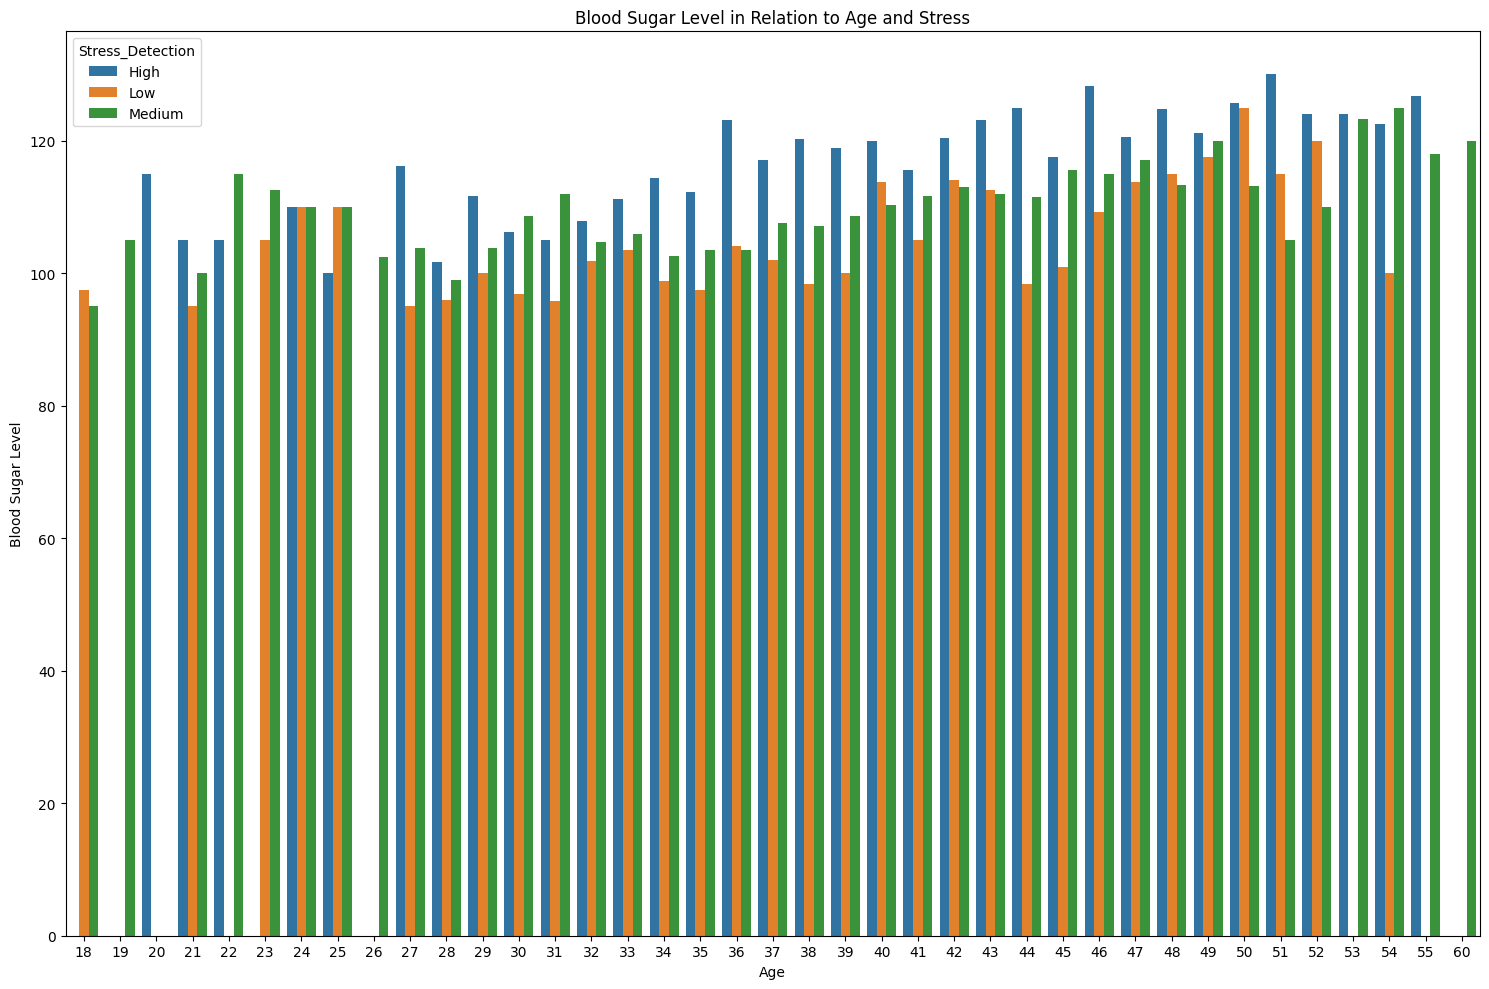

In [26]:
# blood sugar level bar plot
fig, ax = plt.subplots(figsize=(15, 10))

sns.barplot(x='Age', y='Blood_Sugar_Level', hue='Stress_Detection', data=stack_pivot_table, ax=ax)

ax.set_title('Blood Sugar Level in Relation to Age and Stress')
ax.set_xlabel('Age')
ax.set_ylabel('Blood Sugar Level');

plt.tight_layout()
plt.show()

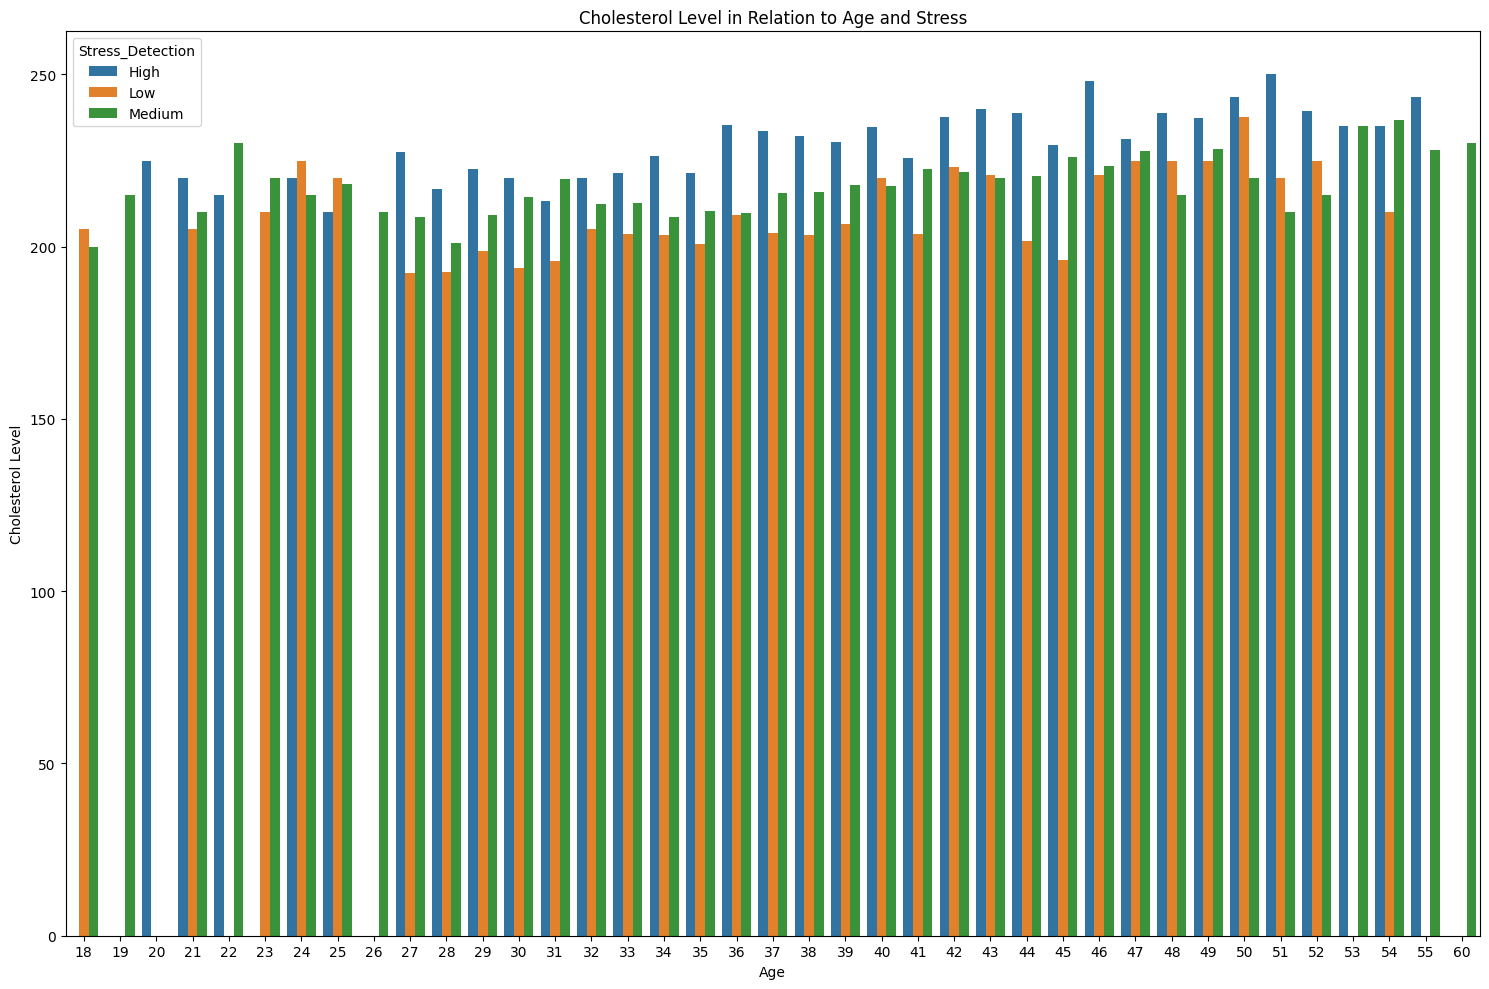

In [27]:
# cholesterol level bar plot
fig, ax = plt.subplots(figsize=(15, 10))

sns.barplot(x='Age', y='Cholesterol_Level', hue='Stress_Detection', data=stack_pivot_table, ax=ax)

ax.set_title('Cholesterol Level in Relation to Age and Stress')
ax.set_xlabel('Age')
ax.set_ylabel('Cholesterol Level')

plt.tight_layout()
plt.show()

plt.savefig("Cholesterol .png")

There is a positive correlation between health and stress.
There is a general trend of `Blood Pressure`, `Blood Sugar Level` and `Cholesterol Levels` increasing with  `Age`

### Explore Work-Related Factors in Relation To Stress

In [28]:
# check the frequency of each occupation
occupation_counts = stress_df['Occupation'].value_counts()

occupation_counts

Occupation
Teacher               37
Chef                  26
Nurse                 23
Photographer          22
Graphic Designer      18
                      ..
Marketing Director     1
Fitness Instructor     1
Biologist              1
Technician             1
Program Manager        1
Name: count, Length: 169, dtype: int64

In [29]:
# create dataframe for each occupation and its frequency
occupation_df = pd.DataFrame({'Occupation': occupation_counts.index, 'count': occupation_counts.values})

frequent_threshold = 10
mid_frequent_threshold = 2

def group_by_frequency(count):
    if count > frequent_threshold:
        return 'Frequent Occupations'
    elif count > mid_frequent_threshold:
        return 'Mid-Frequenct Occupations'
    else:
        return 'Rare Occupations'

occupation_df['Occupation_Grouped'] = occupation_df['count'].apply(group_by_frequency)

occupation_df.head()

,Occupation,count,Occupation_Grouped
0,Teacher,37,Frequent Occupations
1,Chef,26,Frequent Occupations
2,Nurse,23,Frequent Occupations
3,Photographer,22,Frequent Occupations
4,Graphic Designer,18,Frequent Occupations


In [30]:
occupation_df['Occupation_Grouped'].value_counts()

Occupation_Grouped
Rare Occupations             90
Mid-Frequenct Occupations    60
Frequent Occupations         19
Name: count, dtype: int64

In [31]:
# pivot table of occupation, work hours, travel
pivot_table_2 = stress_df.pivot_table(values=['Work_Hours', 'Travel_Time'], index=['Occupation'],  columns='Stress_Detection', aggfunc='mean')
pivot_table_2 = pivot_table_2.sort_index(level='Occupation')

pivot_table_2

Travel_Time                     Work_Hours             
Stress_Detection             High       Low    Medium       High   Low Medium
Occupation                                                                   
Account Manager               NaN       NaN  2.000000        NaN   NaN  7.000
Accountant                   4.00  2.500000  2.833333        8.0  7.50  9.000
Actor                        4.00  2.000000  2.000000        8.0  8.00  8.000
Advertising Executive         NaN       NaN  2.000000        NaN   NaN  8.000
Advertising Manager           NaN  2.000000       NaN        NaN  8.00    NaN
...                           ...       ...       ...        ...   ...    ...
Waitress                     4.00  3.000000       NaN        9.0  7.00    NaN
Warehouse Worker              NaN       NaN  3.000000        NaN   NaN  7.000
Weaver                       3.00  2.000000       NaN        8.0  8.00    NaN
Web Developer                2.75  2.750000  2.375000        8.5  7.25  8.125
Writer                        NaN  2.666667  2.750000        NaN  7.00  8.500

[169 rows x 6 columns]

In [32]:
# convert from wide to long format
work_pivot_table = pivot_table_2.stack(future_stack=True)

work_pivot_table

Travel_Time  Work_Hours
Occupation      Stress_Detection                         
Account Manager High                      NaN         NaN
                Low                       NaN         NaN
                Medium               2.000000       7.000
Accountant      High                 4.000000       8.000
                Low                  2.500000       7.500
...                                       ...         ...
Web Developer   Low                  2.750000       7.250
                Medium               2.375000       8.125
Writer          High                      NaN         NaN
                Low                  2.666667       7.000
                Medium               2.750000       8.500

[507 rows x 2 columns]

In [33]:
work_pivot_table = work_pivot_table.reset_index()
work_pivot_table

,Occupation,Stress_Detection,Travel_Time,Work_Hours
0,Account Manager,High,NaN,NaN
1,Account Manager,Low,NaN,NaN
2,Account Manager,Medium,2.000000,7.000
3,Accountant,High,4.000000,8.000
4,Accountant,Low,2.500000,7.500
...,...,...,...,...
502,Web Developer,Low,2.750000,7.250
503,Web Developer,Medium,2.375000,8.125
504,Writer,High,NaN,NaN
505,Writer,Low,2.666667,7.000


In [34]:
# merge so as to plot using the occupation grouped column with work hours and travel time
df = pd.merge(work_pivot_table, occupation_df, on='Occupation', how='left')

In [35]:
# merged df
df.head()

,Occupation,Stress_Detection,Travel_Time,Work_Hours,count,Occupation_Grouped
0,Account Manager,High,NaN,NaN,1,Rare Occupations
1,Account Manager,Low,NaN,NaN,1,Rare Occupations
2,Account Manager,Medium,2.0,7.0,1,Rare Occupations
3,Accountant,High,4.0,8.0,11,Frequent Occupations
4,Accountant,Low,2.5,7.5,11,Frequent Occupations


In [36]:
work_columns = ['Work_Hours', 'Travel_Time', 'Stress_Level']

<Figure size 640x480 with 0 Axes>

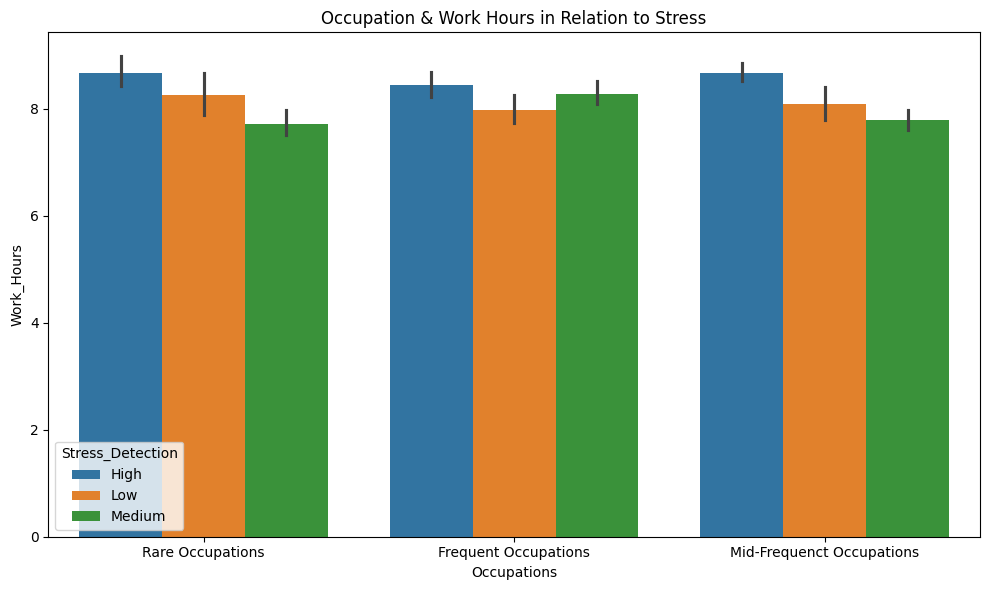

In [37]:

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(x='Occupation_Grouped', y='Work_Hours', hue='Stress_Detection', data=df, ax=ax)

ax.set_title('Occupation & Work Hours in Relation to Stress')
ax.set_xlabel('Occupations')
ax.set_ylabel('Work_Hours')

plt.tight_layout()
plt.show()

Across all occupation groups, employees working high hours report high levels of stress.

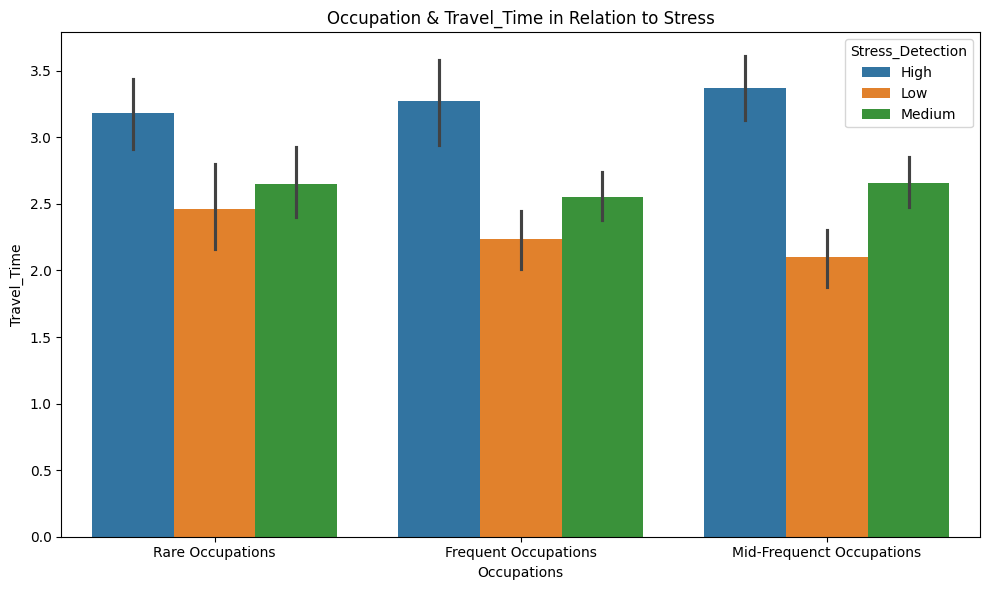

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(x='Occupation_Grouped', y='Travel_Time', hue='Stress_Detection', data=df, ax=ax)

ax.set_title('Occupation & Travel_Time in Relation to Stress')
ax.set_xlabel('Occupations')
ax.set_ylabel('Travel_Time')

plt.tight_layout()
plt.show()

Rare occupations show highest average travel time.

# 